In [50]:
import os

os.environ["KAGGLE_USERNAME"] = "redacted"
os.environ["KAGGLE_KEY"] = "export redacted"

In [51]:
# ===== CONFIGURATION =====
NUM_SAMPLES = 200          # <<< CHANGE THIS TO CONTROL SAMPLE SIZE
MAX_LEN = 512
RANDOM_SEED = 42

import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [52]:
import os, zipfile, pandas as pd

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

with zipfile.ZipFile("fake-and-real-news-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real]).sample(frac=1, random_state=42)
df["text"] = df["title"] + " " + df["text"]
df = df[["text", "label"]]


Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [53]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, _, _ = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [54]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [55]:
def truncate_text(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    return tokenizer.decode(enc["input_ids"][0], skip_special_tokens=True)

truncated_test_texts = [
    truncate_text(t) for t in test_texts[:NUM_SAMPLES]
]

print(f"Using {len(truncated_test_texts)} truncated samples")


Using 200 truncated samples


In [56]:
id2label = {0: "FAKE", 1: "REAL"}
truncated_test_labels = []

for t in truncated_test_texts:
    inputs = tokenizer(t, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_id = logits.argmax(dim=-1).item()
    truncated_test_labels.append(id2label[pred_id])


In [57]:
NUM_REAL = truncated_test_labels.count("REAL")
NUM_FAKE = truncated_test_labels.count("FAKE")

print(f"REAL: {NUM_REAL}")
print(f"FAKE: {NUM_FAKE}")

REAL: 99
FAKE: 101


In [58]:
def predict_label_and_prob(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN,
                    return_tensors="pt").to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1)[0]
    label = probs.argmax().item()
    return label, probs[label].item()


In [59]:
import shap

def shap_model(texts):
    if isinstance(texts, str):
        texts = [texts]
    # Ensure texts is a list of strings for the tokenizer
    texts = [str(t) for t in texts]
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits

    return logits.cpu().numpy()

explainer = shap.Explainer(shap_model, shap.maskers.Text(tokenizer))
shap_values = explainer(truncated_test_texts)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   0%|          | 1/200 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 3/200 [00:39<33:02, 10.07s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer: 100%|█████████▉| 199/200 [42:49<00:10, 10.40s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 200/200 [42:57<00:00,  9.47s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 201it [43:13, 12.97s/it]


In [60]:
def tokens_to_words(tokens, values):
    words, scores = [], []
    cur_w, cur_s = "", 0

    for t, v in zip(tokens, values):
        if t.startswith("##"):
            cur_w += t[2:]
            cur_s += v
        else:
            if cur_w:
                words.append(cur_w)
                scores.append(cur_s)
            cur_w, cur_s = t, v

    if cur_w:
        words.append(cur_w)
        scores.append(cur_s)

    return words, scores


In [61]:
def deletion_experiment(shap_values, texts, max_words=40):
    results = []

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        # SHAP values for predicted class
        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]

        words, scores = tokens_to_words(tokens, values)

        # ✅ KEEP ONLY WORDS ALIGNED WITH PREDICTION
        aligned_words = [
            (w, s) for w, s in zip(words, scores) if s > 0
        ]

        # Sort by strongest support
        aligned_words = sorted(
            aligned_words, key=lambda x: x[1], reverse=True
        )

        for k, (w, _) in enumerate(aligned_words[:max_words]):
            current_text = current_text.replace(w, "")
            new_label, _ = predict_label_and_prob(current_text)

            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": k + 1,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results


In [62]:
del_results = deletion_experiment(shap_values, truncated_test_texts)


In [63]:
import pandas as pd

# Keep only successful flips (ignore None)
del_results_clean = [r for r in del_results if r is not None]

df_deletion_results = pd.DataFrame(del_results_clean)

# Replace numeric labels with readable labels
df_deletion_results["original_label"] = df_deletion_results["original_label"].map({0: "FAKE", 1: "REAL"})
df_deletion_results["new_label"] = df_deletion_results["new_label"].map({0: "FAKE", 1: "REAL"})

df_deletion_results

,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,0,7,.,REAL,FAKE,philippines doctor linked to new york attack p...,philippines doctor linked to new york attack p...
1,1,33,win,REAL,FAKE,"more republicans expect clinton, rather than t...","more republicans expect clinton, rather than t..."
2,3,8,s,REAL,FAKE,those who boycott syrian congress may be sidel...,"thoe who boycott congre may be idelined, ruia ..."
3,4,16,s,REAL,FAKE,burundi opposition platform boycotts new round...,boycottnew round peace talkin tanzania nairobi...
4,6,18,s,REAL,FAKE,u. s. representatives question bank regulator ...,qetiwhitleblower wahingt( reter ) - leader of ...
...,...,...,...,...,...,...,...
84,187,19,.,REAL,FAKE,u. s. appeals court will not put trump travel ...,sappeals will not pt trmp travel ban case hold...
85,188,18,.,REAL,FAKE,clinton to accuse trump of embracing nativist ...,clintto accuse trump of embracing nativist mov...
86,189,12,on,REAL,FAKE,turkey suggests plan to extend military missio...,suggests plan to extend military missisyrito a...
87,194,34,g,REAL,FAKE,epa nominee will review vehicle emissions rule...,epa nominee review vehicle emissions rules was...


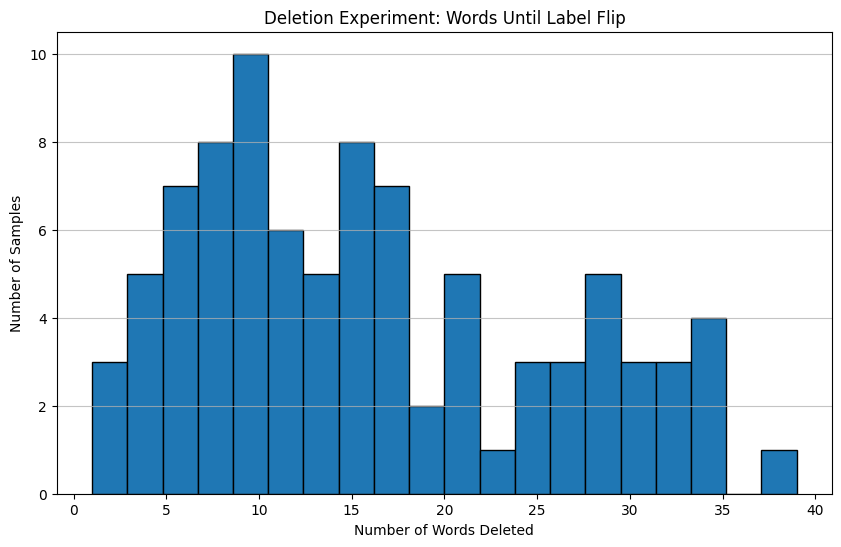

In [64]:
import matplotlib.pyplot as plt

# Extract number of deleted words until flip
num_words_until_flip = df_deletion_results["num_words"]

plt.figure(figsize=(10, 6))
plt.hist(num_words_until_flip, bins=20, edgecolor="black")
plt.title("Deletion Experiment: Words Until Label Flip")
plt.xlabel("Number of Words Deleted")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [65]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download("wordnet")

def get_synonym(word):
    for syn in wn.synsets(word):
        for l in syn.lemmas():
            if l.name().lower() != word.lower():
                return l.name().replace("_", " ")
    return None


def substitution_experiment(shap_values, texts, max_words=40):
    results = []

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]
        words, scores = tokens_to_words(tokens, values)

        # SHAP values for predicted class
        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]

        words, scores = tokens_to_words(tokens, values)

        # ✅ KEEP ONLY WORDS ALIGNED WITH PREDICTION
        aligned_words = [
            (w, s) for w, s in zip(words, scores) if s > 0
        ]

        # Sort by strongest support
        aligned_words = sorted(
            aligned_words, key=lambda x: x[1], reverse=True
        )

        changed = 0
        for w, _ in aligned_words[:max_words]:
            syn = get_synonym(w)
            if not syn:
                continue
            current_text = current_text.replace(w, syn, 1)
            changed += 1
            new_label, _ = predict_label_and_prob(current_text)
            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": changed,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [66]:
sub_results = substitution_experiment(shap_values, truncated_test_texts)


In [67]:
sub_results

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 {'num_sample': 35,
  'num_words': 3,
  'word': 'said',
  'original_label': 1,
  'new_label': 0,
  'original_text': 'the boss is dead but the mafia lives, magistrate and mobster say rome / palermo ( reuters ) - the death of sicilian mafia boss salvatore toto riina on friday does not mark the end of cosa nostra, but the crime group is unlikely to allow one man such power ever again, a top magistrate and former mobster said. the 87 - year - old riina died in a hospital in parma, the northern italian city where he had been serving 26 life sentences for murders committed between 1969 and 1992. the end of riina isn t the end of cosa nostra, the chief magistrate in sicily s capital of palermo, francesco lo voi, told reuters. what remains to be underst

In [68]:
# Keep only successful flips (ignore None)
sub_results_clean = [r for r in sub_results if r is not None]

df_substitution_results = pd.DataFrame(sub_results_clean)

# Replace numeric labels with readable labels
df_substitution_results["original_label"] = df_substitution_results["original_label"].map({0: "FAKE", 1: "REAL"})
df_substitution_results["new_label"] = df_substitution_results["new_label"].map({0: "FAKE", 1: "REAL"})

df_substitution_results

,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,35,3,said,REAL,FAKE,"the boss is dead but the mafia lives, magistra...","the boss iodines dead but the mafia lives, mag..."
1,139,1,monday,REAL,FAKE,clinton clinches democratic nomination : ap de...,clinton clinches democratic nomination : ap de...


In [69]:
def count_char_differences(a: str, b: str) -> int:
    # Ensure a is the shorter string (for fewer shifts)
    if len(a) > len(b):
        a, b = b, a

    min_differences = float("inf")

    # Try all possible alignments of a against b
    for offset in range(len(b) - len(a) + 1):
        # Compare overlapping region
        differences = sum(
            c1 != c2 for c1, c2 in zip(a, b[offset:offset + len(a)])
        )

        # Add differences for non-overlapping parts
        differences += offset                      # leading extra chars
        differences += len(b) - (offset + len(a)) # trailing extra chars

        min_differences = min(min_differences, differences)

    return min_differences


In [70]:
def ae(label, df_results):
    df_results = df_results[df_results["original_label"] == label]

    if label == "REAL":
        return len(df_results) / NUM_REAL
    else:
        return len(df_results) / NUM_FAKE


def ci(label, df_results):
    df_results = df_results[df_results["original_label"] == label]

    n_characters_modified = 0

    for i, row in df_results.iterrows():
        n_characters_modified += count_char_differences(row["original_text"], row["new_text"])

    if label == "REAL":
        if len(df_results) == 0:
            return 0
        return n_characters_modified / len(df_results)
    else:
        if len(df_results) == 0:
            return 0
        return n_characters_modified / len(df_results)

def pi(label, df_results):
    df_results = df_results[df_results["original_label"] == label]

    percentage_modified = 0

    for i, row in df_results.iterrows():
        percentage_modified += count_char_differences(row["original_text"], row["new_text"]) / len(row["original_text"])

    if label == "REAL":
        if len(df_results) == 0:
            return 0
        return percentage_modified / len(df_results)
    else:
        if len(df_results) == 0:
            return 0
        return percentage_modified / len(df_results)

In [71]:
ae_real = ae(label="REAL", df_results=df_substitution_results)
ae_fake = ae(label="FAKE", df_results=df_substitution_results)

ci_real = ci(label="REAL", df_results=df_substitution_results)
ci_fake = ci(label="FAKE", df_results=df_substitution_results)

pi_real = pi(label="REAL", df_results=df_substitution_results)
pi_fake = pi(label="FAKE", df_results=df_substitution_results)



In [72]:
print(f"AE REAL: {ae_real}")
print(f"AE FAKE: {ae_fake}")

print(f"CI REAL: {ci_real}")
print(f"CI FAKE: {ci_fake}")

print(f"PI REAL: {pi_real}")
print(f"PI FAKE: {pi_fake}")

AE REAL: 0.020202020202020204
AE FAKE: 0.0
CI REAL: 260.5
CI FAKE: 0
PI REAL: 0.19041342477123735
PI FAKE: 0


In [73]:
def show_metric_comparison(df_results, name):

  ae_real = ae("REAL", df_results)
  ae_fake = ae("FAKE", df_results)

  ci_real = ci("REAL", df_results)
  ci_fake = ci("FAKE", df_results)

  pi_real = pi("REAL", df_results)
  pi_fake = pi("FAKE", df_results)

  print(f"AE REAL: {ae_real}")
  print(f"AE FAKE: {ae_fake}")

  print(f"CI REAL: {ci_real}")
  print(f"CI FAKE: {ci_fake}")

  print(f"PI REAL: {pi_real}")
  print(f"PI FAKE: {pi_fake}")

  metrics = ["AE", "CI", "PI"]
  real_values = [ae_real, ci_real, pi_real]
  fake_values = [ae_fake, ci_fake, pi_fake]

  x = np.arange(len(metrics))
  width = 0.35


  for i, metric in enumerate(metrics):
      plt.figure(figsize=(6, 4))

      plt.bar(0 - width/2, real_values[i], width, label="REAL")
      plt.bar(0 + width/2, fake_values[i], width, label="FAKE")

      plt.xticks([0], [metric])
      plt.ylabel("Metric value")
      plt.title(f"{name}: REAL vs FAKE — {metric}")
      plt.legend()
      plt.grid(axis="y", linestyle="--", alpha=0.5)

      plt.tight_layout()
      plt.show()

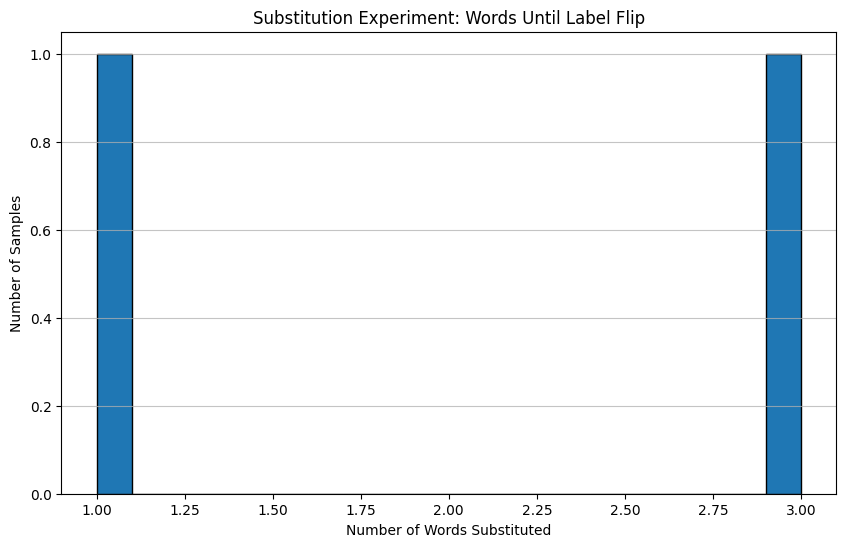

In [74]:
num_words_until_flip = df_substitution_results["num_words"]

plt.figure(figsize=(10, 6))
plt.hist(num_words_until_flip, bins=20, edgecolor="black")
plt.title("Substitution Experiment: Words Until Label Flip")
plt.xlabel("Number of Words Substituted")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()

AE REAL: 0.020202020202020204
AE FAKE: 0.0
CI REAL: 260.5
CI FAKE: 0
PI REAL: 0.19041342477123735
PI FAKE: 0


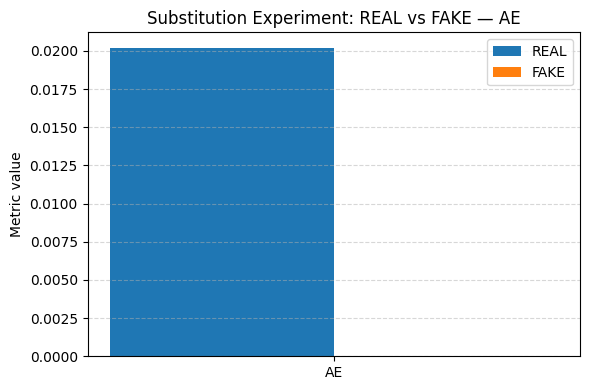

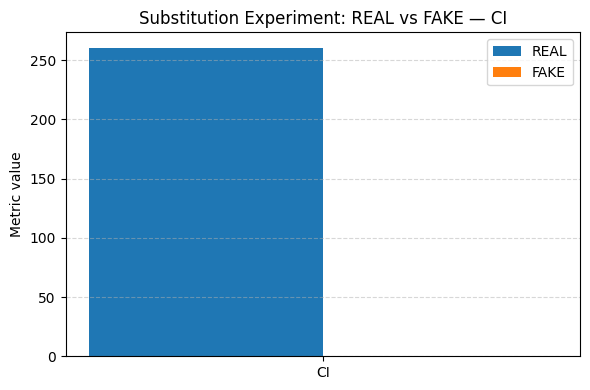

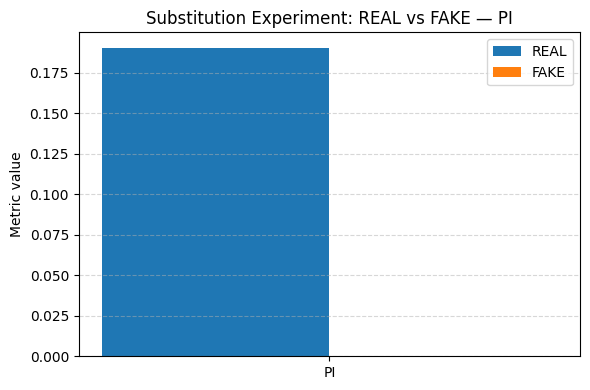

In [75]:
show_metric_comparison(df_substitution_results, "Substitution Experiment")

In [76]:
from collections import defaultdict

def build_global_shap_words(shap_values):
    fake, real = defaultdict(float), defaultdict(float)

    for i in range(len(shap_values.values)):
        tokens = shap_values.data[i]
        vals = shap_values.values[i]
        for t, v in zip(tokens, vals):
            if t.isalpha():
                fake[t.lower()] += v[0]
                real[t.lower()] += v[1]

    return (
        sorted(fake, key=fake.get, reverse=True),
        sorted(real, key=real.get, reverse=True)
    )

fake_words, real_words = build_global_shap_words(shap_values)


In [77]:
fake_words

['images',
 'com',
 'sun',
 'get',
 't',
 'news',
 'words',
 'america',
 'tv',
 'journal',
 'commons',
 'fox',
 'rip',
 'well',
 'come',
 'today',
 'anger',
 'b',
 'whoa',
 'c',
 'all',
 'lo',
 'bar',
 'eit',
 'pic',
 'now',
 'ny',
 'br',
 'l',
 'fault',
 'je',
 'real',
 'do',
 'un',
 'ridiculous',
 'is',
 'w',
 'this',
 'time',
 'heavy',
 'the',
 'apparently',
 'he',
 'z',
 'og',
 'ops',
 'out',
 'again',
 'cars',
 'faust',
 'go',
 'rails',
 'boss',
 'pen',
 'mail',
 'morning',
 'hr',
 'der',
 'brand',
 'rub',
 'twitter',
 'ulia',
 'it',
 'x',
 'put',
 'accuse',
 'so',
 'sh',
 'zone',
 'at',
 'plane',
 'story',
 'available',
 'gi',
 'him',
 'spoken',
 'money',
 'up',
 'years',
 'don',
 'oc',
 'ru',
 'fact',
 'here',
 'enforcement',
 'hillary',
 'god',
 'yes',
 'why',
 'red',
 'bl',
 'o',
 'sc',
 'damn',
 'wee',
 'you',
 'protest',
 'purpose',
 'thing',
 'v',
 'trum',
 'oh',
 'men',
 'no',
 'ne',
 'her',
 'read',
 'mas',
 'berman',
 'really',
 'wire',
 'a',
 'int',
 'sher',
 'pi',
 'r'

In [78]:
real_words

['said',
 'u',
 's',
 'tuesday',
 'thursday',
 'monday',
 'wednesday',
 'friday',
 'sunday',
 'statement',
 'nov',
 'till',
 'law',
 'election',
 'militants',
 'ministers',
 'ex',
 'week',
 'p',
 'saturday',
 'd',
 'lebanon',
 'ka',
 'na',
 'officials',
 'capital',
 'valencia',
 'reporters',
 'clinton',
 'france',
 'month',
 'za',
 'oct',
 'hari',
 'la',
 'mer',
 'n',
 'spain',
 'ku',
 'year',
 'ass',
 'pr',
 'zar',
 'bay',
 'vr',
 'ta',
 'an',
 'residents',
 'says',
 'jihad',
 'feb',
 'briefing',
 'nty',
 'kan',
 'sa',
 'id',
 'delegation',
 'em',
 'comment',
 'kabul',
 'dah',
 'release',
 'gu',
 'reuters',
 'state',
 'rev',
 'side',
 'country',
 'vi',
 'vote',
 'zimbabwe',
 'iam',
 'agency',
 'ar',
 'cnn',
 'jan',
 'committee',
 'turk',
 'conference',
 'region',
 'afghanistan',
 'government',
 'ip',
 'ral',
 'britain',
 'f',
 'ma',
 'aide',
 'ci',
 'det',
 'bo',
 'boycott',
 'debt',
 'may',
 'spoke',
 'scar',
 'da',
 'senate',
 'critic',
 'trump',
 'e',
 'al',
 're',
 'co',
 'office'

In [79]:
import random

def injection_experiment(texts, fake_words, real_words, max_words=40, seed=42):
    results = []

    random.seed(seed)  # reproducibility

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        # Choose word pool that pushes toward the opposite class
        word_pool = real_words if orig_label == 0 else fake_words

        changed = 0

        for w in word_pool[:max_words]:
            changed += 1

            # ---- RANDOM POSITION INJECTION ----
            words = current_text.split()
            insert_idx = random.randint(0, len(words))
            words.insert(insert_idx, w)
            current_text = " ".join(words)
            # -----------------------------------

            new_label, _ = predict_label_and_prob(current_text)

            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": changed,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results



In [80]:
import pandas as pd

inj_results = injection_experiment(
    truncated_test_texts,
    fake_words,
    real_words
)

inj_results_clean = [r for r in inj_results if r is not None]

df_injection_results = pd.DataFrame(inj_results_clean)

df_injection_results["original_label"] = df_injection_results[
    "original_label"
].map({0: "FAKE", 1: "REAL"})

df_injection_results["new_label"] = df_injection_results[
    "new_label"
].map({0: "FAKE", 1: "REAL"})

df_injection_results


,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,0,18,b,REAL,FAKE,philippines doctor linked to new york attack p...,philippines doctor linked to new york attack p...
1,3,20,c,REAL,FAKE,those who boycott syrian congress may be sidel...,those who boycott syrian congress may be sidel...
2,11,11,commons,REAL,FAKE,iraqi forces remove kurdish flag from kirkuk g...,iraqi forces com remove kurdish flag from kirk...
3,13,33,do,REAL,FAKE,man killed with arrows in kenyan village on ed...,man news killed with whoa arrows in kenyan vil...
4,18,7,words,REAL,FAKE,trump : decision on immigrant children coming ...,trump : decision on immigrant children get com...
5,22,8,america,REAL,FAKE,russia probe special counsel interviews ex - t...,russia probe special counsel interviews ex - t...
6,27,25,pic,REAL,FAKE,"nigerian police kill one, arrest two suspects ...","nigerian police kill one, images arrest two su..."
7,30,12,fox,REAL,FAKE,police investigating militants search brussels...,police investigating militants search brussels...
8,35,17,anger,REAL,FAKE,"the boss is dead but the mafia lives, magistra...","the boss is dead but the mafia lives, magistra..."
9,38,28,br,REAL,FAKE,iraq refuses talks with kurds unless they comm...,iraq refuses talks with kurds unless they comm...


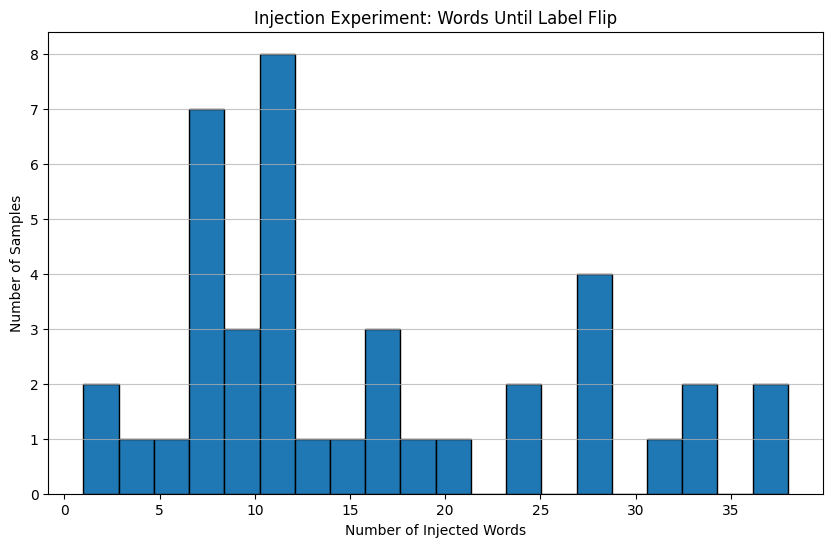

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_injection_results["num_words"], bins=20, edgecolor="black")
plt.title("Injection Experiment: Words Until Label Flip")
plt.xlabel("Number of Injected Words")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()


AE REAL: 0.8585858585858586
AE FAKE: 0.039603960396039604
CI REAL: 1682.129411764706
CI FAKE: 254.75
PI REAL: 0.8435921656411192
PI FAKE: 0.5827037545787546


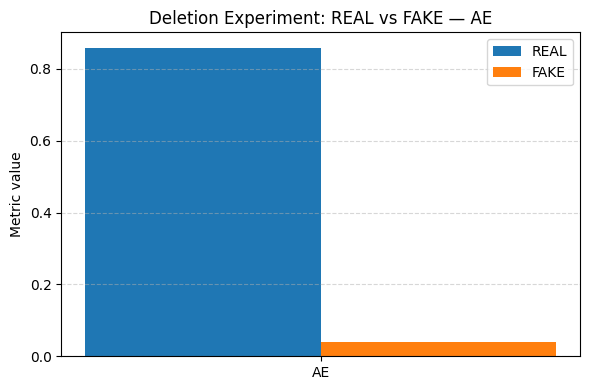

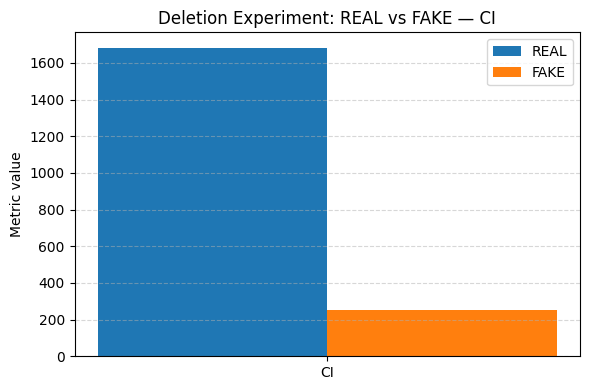

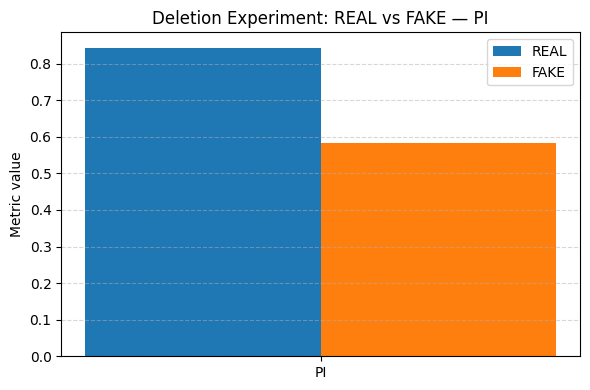

In [82]:
show_metric_comparison(df_deletion_results, "Deletion Experiment")

AE REAL: 0.020202020202020204
AE FAKE: 0.0
CI REAL: 260.5
CI FAKE: 0
PI REAL: 0.19041342477123735
PI FAKE: 0


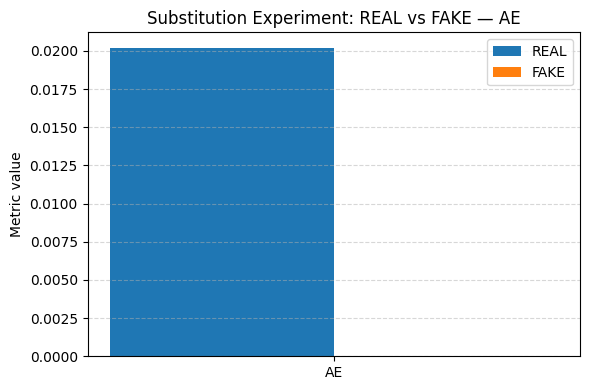

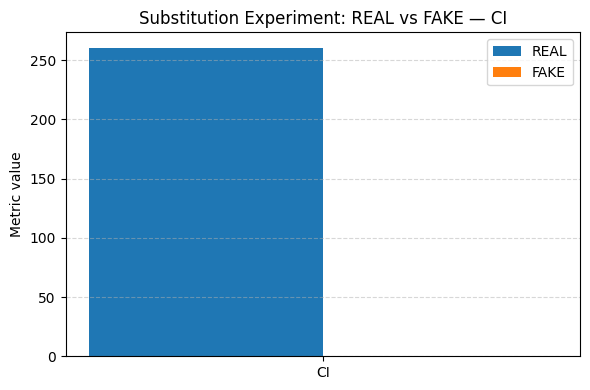

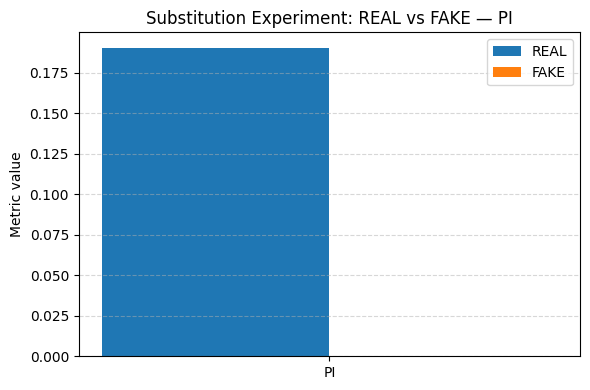

In [83]:
show_metric_comparison(df_substitution_results, "Substitution Experiment")

AE REAL: 0.3838383838383838
AE FAKE: 0.019801980198019802
CI REAL: 908.6052631578947
CI FAKE: 141.0
PI REAL: 0.7515609916442978
PI FAKE: 1.6179653679653678


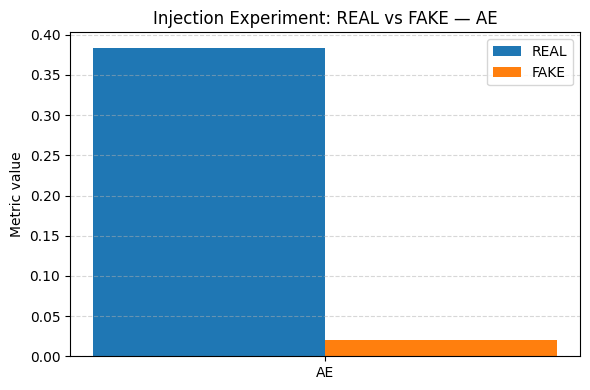

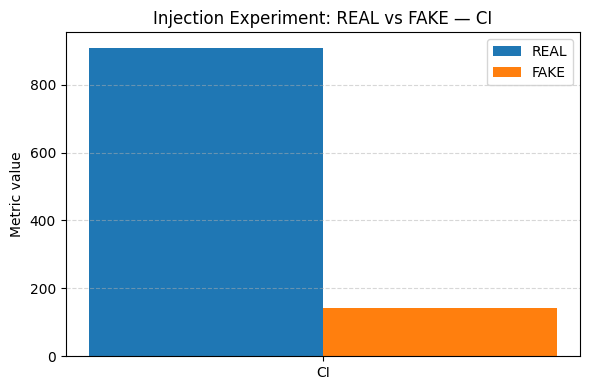

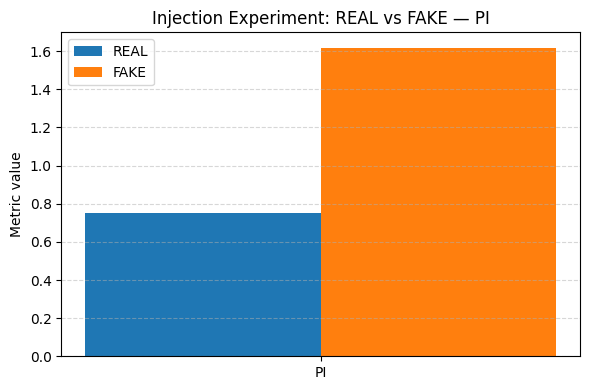

In [84]:
show_metric_comparison(df_injection_results, "Injection Experiment")